In [100]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

df = pd.read_csv("../data/Crop_recommendation.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


# EDA and Data Cleaning

In [101]:
df.tail()

,N,P,K,temperature,humidity,ph,rainfall,label
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee
2199,104,18,30,23.603016,60.396475,6.779833,140.937041,coffee


In [102]:
df.shape

(2200, 8)

In [103]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [104]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [105]:
df.duplicated().sum()

np.int64(0)

In [106]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [107]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [108]:
# Install it first via pip: pip install ydata-profiling
from ydata_profiling import ProfileReport

# The one-liner that builds and displays the entire EDA report
ProfileReport(df).to_notebook_iframe()


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 1374.62it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

<Axes: xlabel='count', ylabel='label'>

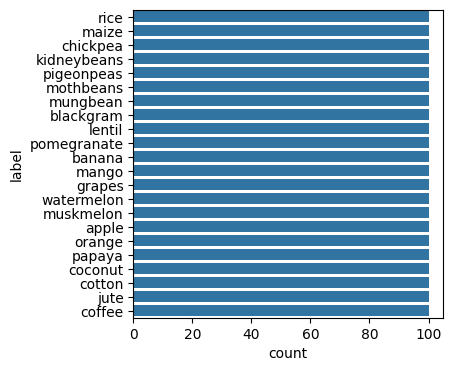

In [109]:
plt.figure(figsize=(4,4))
sns.countplot(y=df["label"])

In [110]:
cols = ['N', 'P', 'temperature', 'ph', 'rainfall']


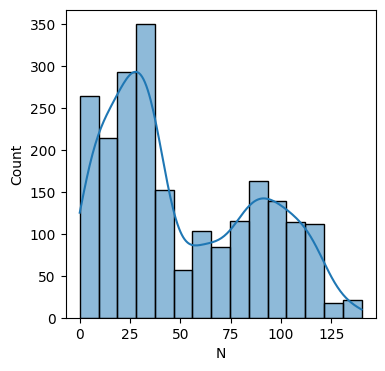

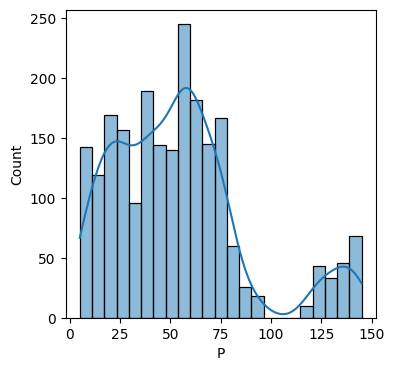

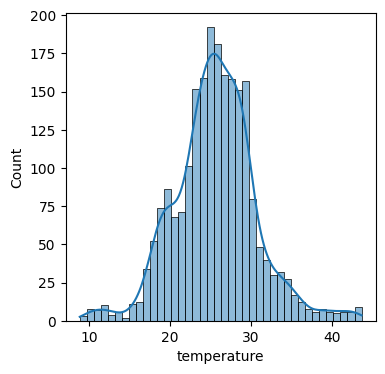

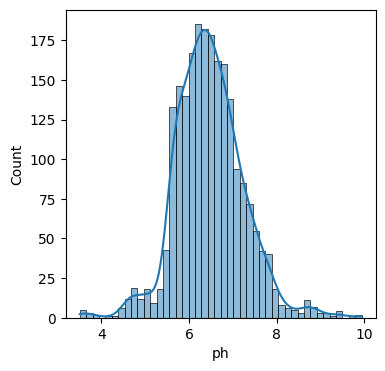

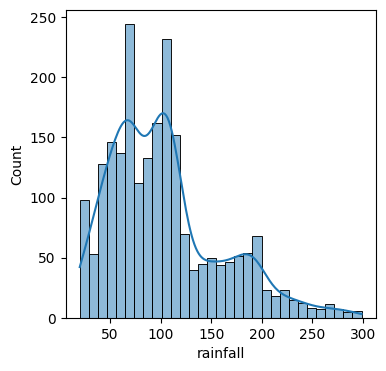

In [111]:
for col in cols:
    plt.figure(figsize=(4,4))
    sns.histplot(x=col,data=df,kde=True)
    

<Axes: xlabel='humidity'>

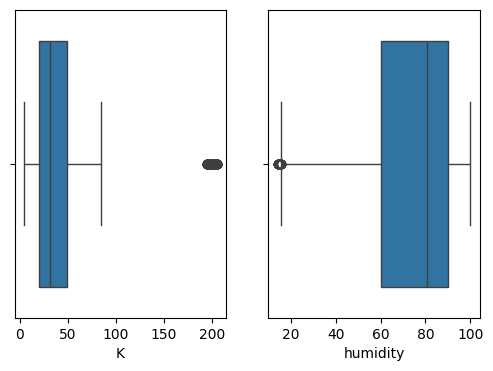

In [112]:
plt.figure(figsize=(6,4))
plt.subplot(1,2,1)
sns.boxplot(x=df["K"])
plt.subplot(1,2,2)
sns.boxplot(x=df["humidity"])

<Axes: >

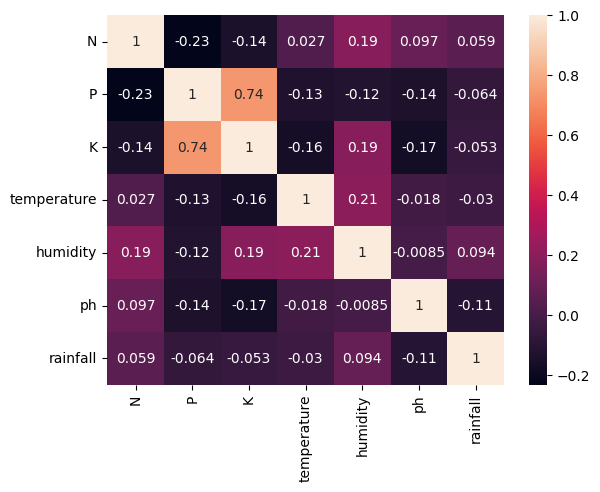

In [113]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [114]:
# Har crop ke average requirements
crop_summary = df.groupby("label").mean()
crop_summary

,N,P,K,temperature,humidity,ph,rainfall
label,,,,,,,
apple,20.80,134.22,199.89,22.630942,92.333383,5.929663,112.654779
banana,100.23,82.01,50.05,27.376798,80.358123,5.983893,104.626980
blackgram,40.02,67.47,19.24,29.973340,65.118426,7.133952,67.884151
chickpea,40.09,67.79,79.92,18.872847,16.860439,7.336957,80.058977
coconut,21.98,16.93,30.59,27.409892,94.844272,5.976562,175.686646
coffee,101.20,28.74,29.94,25.540477,58.869846,6.790308,158.066295
cotton,117.77,46.24,19.56,23.988958,79.843474,6.912675,80.398043
grapes,23.18,132.53,200.11,23.849575,81.875228,6.025937,69.611829
jute,78.40,46.86,39.99,24.958376,79.639864,6.732778,174.792798


# Feature Engineerig 

In [115]:
df['ph_category'] = pd.cut(
    df['ph'], 
    bins=[0, 5.5, 6.5, 7.5, 8.5, 14], 
    labels=['strongly_acidic', 'moderately_acidic', 'neutral', 'alkaline', 'strongly_alkaline']
)

In [116]:
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label,ph_category
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice,neutral
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice,neutral
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice,alkaline
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice,neutral
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice,alkaline


# Data Preprocessing

In [117]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split


def build_pipeline():
    num_cols = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']
    cat_cols =  ['ph_category']

    num_pipeline = Pipeline(steps=[
        ("imputing",SimpleImputer(strategy="mean")),
        ("scaling", StandardScaler())
    ])

    cat_pipeline = Pipeline(steps=[
        ("imputing",SimpleImputer(strategy="most_frequent")),
        ("encoding",OneHotEncoder(handle_unknown='ignore'))
    ])

    final_pipeline = ColumnTransformer(transformers=[
        ("num cols",num_pipeline,num_cols),
        ("cat_cols",cat_pipeline,cat_cols)
    ])

    return final_pipeline

In [118]:
X = df.drop(columns=["label"],axis=1)
y = df["label"]

x_train,x_test,y_train,y_test = train_test_split(X,y,
                                                random_state=42,
                                                test_size=0.20 )


In [119]:
from sklearn.preprocessing import LabelEncoder

pipeline = build_pipeline()
X_train_encoded = pipeline.fit_transform(x_train)
X_test_encoded = pipeline.transform(x_test)

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Model Selection

In [120]:
from sklearn.ensemble import GradientBoostingClassifier,RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [121]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Support Vector Machine": SVC(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

In [122]:
results = []

for name, model in models.items():
    model.fit(X_train_encoded, y_train_encoded)
    y_pred = model.predict(X_test_encoded)
    
    acc = accuracy_score(y_test_encoded, y_pred)
    prec = precision_score(y_test_encoded, y_pred, average="weighted")
    rec = recall_score(y_test_encoded, y_pred, average="weighted")
    f1 = f1_score(y_test_encoded, y_pred, average="weighted")
    
    results.append(
      {
          "Model": name,
          "Accuracy": acc,
          "Precision": prec,
          "Recall": rec,
          "F1 Score": f1,
      }
    )


# Model Evaluation

In [123]:
result = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
result 

,Model,Accuracy,Precision,Recall,F1 Score
5,Random Forest,0.993182,0.993735,0.993182,0.993175
4,Decision Tree,0.988636,0.988997,0.988636,0.988595
6,Gradient Boosting,0.984091,0.985862,0.984091,0.983952
3,Support Vector Machine,0.965909,0.972426,0.965909,0.966056
0,Logistic Regression,0.961364,0.964376,0.961364,0.961000
1,KNN,0.956818,0.964957,0.956818,0.956932
2,Naive Bayes,0.852273,0.894591,0.852273,0.832190


C:\Users\Yash\AppData\Local\Temp\ipykernel_10656\107175420.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result, x="Model", y=r, palette="mako")


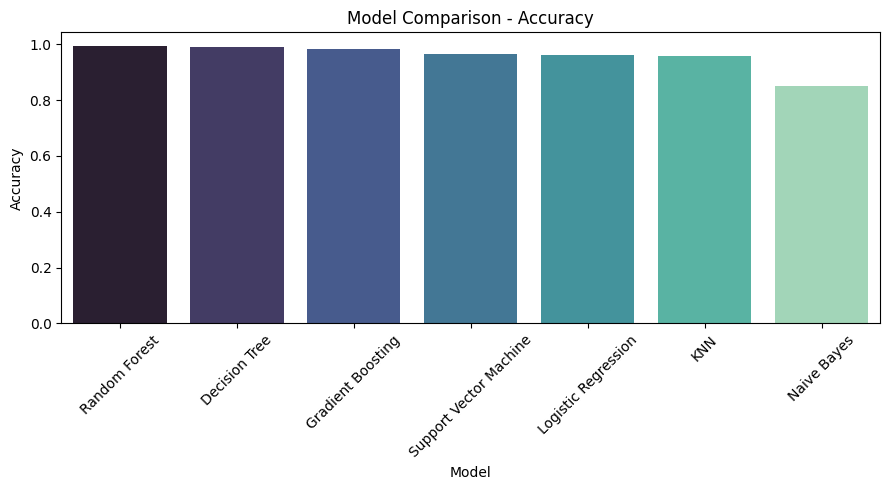

C:\Users\Yash\AppData\Local\Temp\ipykernel_10656\107175420.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result, x="Model", y=r, palette="mako")


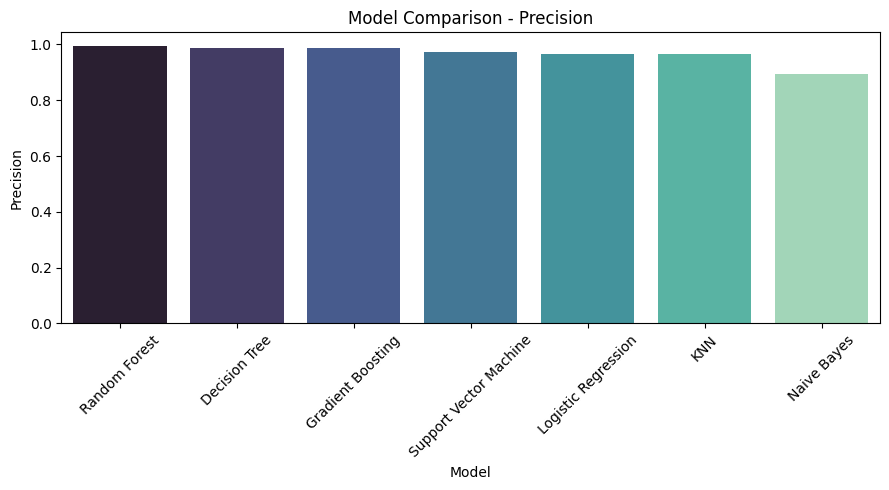

C:\Users\Yash\AppData\Local\Temp\ipykernel_10656\107175420.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result, x="Model", y=r, palette="mako")


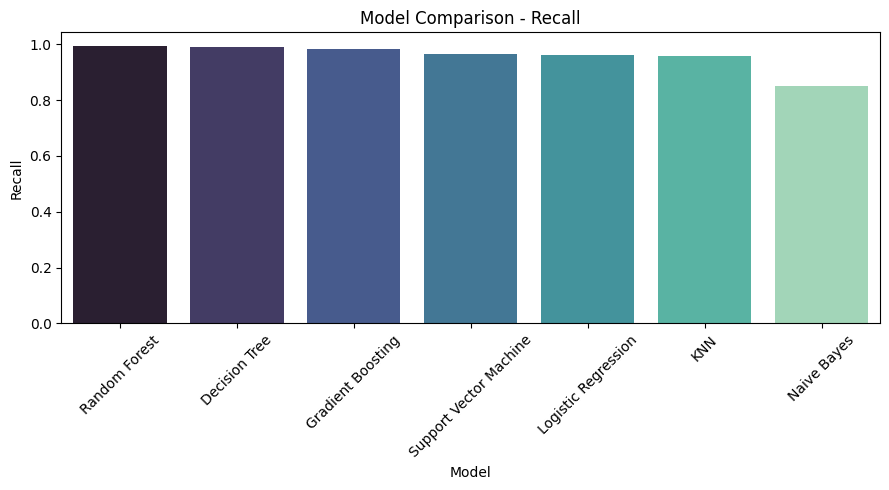

C:\Users\Yash\AppData\Local\Temp\ipykernel_10656\107175420.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result, x="Model", y=r, palette="mako")


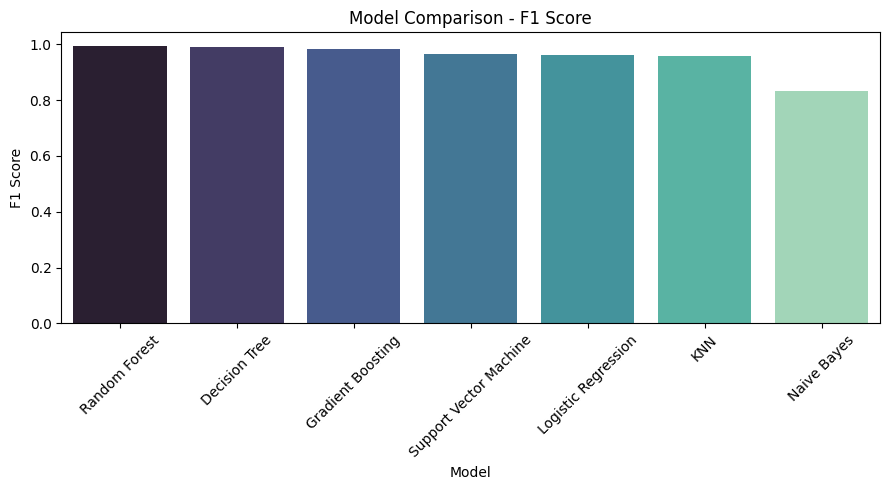

In [124]:
results_cols = ["Accuracy", "Precision", "Recall", "F1 Score"]

for r in results_cols:
  plt.figure(figsize=(9, 5))
  sns.barplot(data=result, x="Model", y=r, palette="mako")
  plt.title(f"Model Comparison - {r}")
  plt.xticks(rotation=45)
  plt.tight_layout()
  plt.show() 

#### Hare Random forest perform a best then all of the given model it has a highest accuracy  with the 99.31 % so We final a this model for Production 